# LensWord — Model Training (Fixed)

This notebook trains the Bidirectional LSTM model.

**Fixes applied from advisor review:**
- Loads X_train.pt only — stale SMOTE cell removed (Error 1)
- Checkpoint selected on validation Macro F1, not accuracy (Error 9)
- Early stopping on Macro F1 (Error 9)
- AdamW optimizer with weight decay for regularization (Error 9)
- Gradient clipping added
- Broken ensemble cell removed (Error 7)
- Class weights computed from inverse frequency (not hardcoded)
- Results saved to models/metrics.json for provenance (Error 10)

Before running: make sure `02_preprocessing_lensword.ipynb` has been run first.

In [1]:
# ── CELL 1: Set random seed and import libraries ──
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import f1_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
import json
import sys
import os
import random

# Set seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

sys.path.append(os.path.abspath('..'))
from src.config import *

print(f"Random seed: {SEED}")
print(f"PyTorch version: {torch.__version__}")

Random seed: 42
PyTorch version: 2.12.1+cpu


In [2]:
# ── CELL 2: Load tensors (X_train.pt only — no SMOTE) ──
# Error 1 fix: load X_train.pt directly — stale X_train_smote.pt removed
# SMOTE is invalid on token-index sequences (Error 5)
# Class imbalance is handled by inverse-frequency class weights below

X_train = torch.load('../data/X_train.pt', weights_only=True)
X_val   = torch.load('../data/X_val.pt',   weights_only=True)
X_test  = torch.load('../data/X_test.pt',  weights_only=True)
y_train = torch.load('../data/y_train.pt', weights_only=True)
y_val   = torch.load('../data/y_val.pt',   weights_only=True)
y_test  = torch.load('../data/y_test.pt',  weights_only=True)

print("Tensors loaded successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

Tensors loaded successfully!
X_train shape: torch.Size([7720, 50])
X_val shape:   torch.Size([1544, 50])
X_test shape:  torch.Size([1030, 50])


In [3]:
# ── CELL 3: Create DataLoaders ──
train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val,   y_val)
test_dataset  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders created!")
print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

DataLoaders created!
Training batches:   242
Validation batches: 49
Test batches:       33


In [4]:
# ── CELL 4: Import model architecture from src/model.py ──
# Single definition in src/model.py — imported here (DRY principle)
import sys
import os
sys.path.append(os.path.abspath('../src'))
from model import LensWordLSTM

print("LensWordLSTM imported from src/model.py!")


LensWordLSTM imported from src/model.py!


In [5]:
# ── CELL 5: Initialize model ──
model = LensWordLSTM(
    vocab_size=MAX_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
)

print(model)
print(f"\nTotal Parameters: {sum(p.numel() for p in model.parameters()):,}")

LensWordLSTM(
  (embedding): Embedding(4340, 64, padding_idx=0)
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)

Total Parameters: 444,035


In [6]:
# ── CELL 6: Loss, optimizer, scheduler ──
# Manual class weights — upweight Negative and Neutral
# which are harder to classify correctly
label_counts = np.bincount(y_train.numpy())
total = label_counts.sum()
class_weights = torch.tensor(
    [total / (NUM_CLASSES * c) for c in label_counts],
    dtype=torch.float
)
print(f"Class weights (inverse freq): {class_weights.numpy().round(3)}")
criterion = nn.CrossEntropyLoss(weight=class_weights)

# AdamW with weight decay for regularization
optimizer = optim.AdamW(model.parameters(),
                        lr=LEARNING_RATE,
                        weight_decay=1e-4)

# Scheduler steps on validation loss
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2)

print(f"\nOptimizer: AdamW (lr={LEARNING_RATE}, weight_decay=1e-4)")
print(f"Scheduler: ReduceLROnPlateau (patience=2, factor=0.5)")


Class weights (inverse freq): [0.926 0.952 1.149]

Optimizer: AdamW (lr=0.001, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau (patience=2, factor=0.5)


In [7]:
# ── CELL 7: Training and evaluation functions ──
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()

        # Gradient clipping prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss += loss.item()
        predicted_labels = predictions.argmax(dim=1)
        correct += (predicted_labels == batch_y).sum().item()
        total += batch_y.size(0)

    return total_loss / len(loader), correct / total * 100


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            total_loss += loss.item()
            predicted_labels = predictions.argmax(dim=1)
            all_preds.extend(predicted_labels.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels) * 100
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), accuracy, macro_f1

print("Training and evaluation functions defined!")
print("Note: checkpoint selection uses Macro F1, not accuracy")

Training and evaluation functions defined!
Note: checkpoint selection uses Macro F1, not accuracy


In [8]:
# ── CELL 8: Training loop ──
# Error 9 fix: checkpoint on Macro F1 (not accuracy)
# Error 9 fix: early stopping on Macro F1
# Error 7 fix: broken ensemble cell replaced with working single-model training

os.makedirs('../models', exist_ok=True)
MODEL_SAVE_PATH = '../models/lensword_model.pt'

train_losses      = []
val_losses        = []
train_accuracies  = []
val_accuracies    = []
val_macro_f1s     = []
best_val_macro_f1 = 0.0
patience          = 5
epochs_no_improve = 0

print("Starting training...")
print(f"Seed: {SEED} | Optimizer: AdamW | Weight decay: 1e-4")
print(f"Checkpoint metric: Validation Macro F1")
print(f"Early stopping patience: {patience} epochs on Macro F1")
print("=" * 75)

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    val_macro_f1s.append(val_f1)

    # Checkpoint on Macro F1 — not accuracy
    if val_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_f1
        epochs_no_improve = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        saved = "✅ Best model saved!"
    else:
        epochs_no_improve += 1
        saved = f"⚠️ No improvement ({epochs_no_improve}/{patience})"

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"Val F1: {val_f1:.4f} | LR: {current_lr:.6f} {saved}")

    if epochs_no_improve >= patience:
        print("\n⛔ Early stopping triggered!")
        break

print("=" * 75)
print(f"Training complete!")
print(f"Best Validation Macro F1: {best_val_macro_f1:.4f}")

Starting training...
Seed: 42 | Optimizer: AdamW | Weight decay: 1e-4
Checkpoint metric: Validation Macro F1
Early stopping patience: 5 epochs on Macro F1
Epoch 01/25 | Train Loss: 0.9129 | Train Acc: 54.33% | Val Loss: 0.7918 | Val Acc: 65.28% | Val F1: 0.6567 | LR: 0.001000 ✅ Best model saved!
Epoch 02/25 | Train Loss: 0.7107 | Train Acc: 68.87% | Val Loss: 0.7308 | Val Acc: 68.72% | Val F1: 0.6889 | LR: 0.001000 ✅ Best model saved!
Epoch 03/25 | Train Loss: 0.6079 | Train Acc: 74.13% | Val Loss: 0.7462 | Val Acc: 68.39% | Val F1: 0.6829 | LR: 0.001000 ⚠️ No improvement (1/5)
Epoch 04/25 | Train Loss: 0.5454 | Train Acc: 77.66% | Val Loss: 0.6666 | Val Acc: 71.11% | Val F1: 0.7152 | LR: 0.001000 ✅ Best model saved!
Epoch 05/25 | Train Loss: 0.4676 | Train Acc: 81.30% | Val Loss: 0.6925 | Val Acc: 72.22% | Val F1: 0.7239 | LR: 0.001000 ✅ Best model saved!
Epoch 06/25 | Train Loss: 0.4119 | Train Acc: 83.99% | Val Loss: 0.7827 | Val Acc: 70.21% | Val F1: 0.7024 | LR: 0.001000 ⚠️ No imp

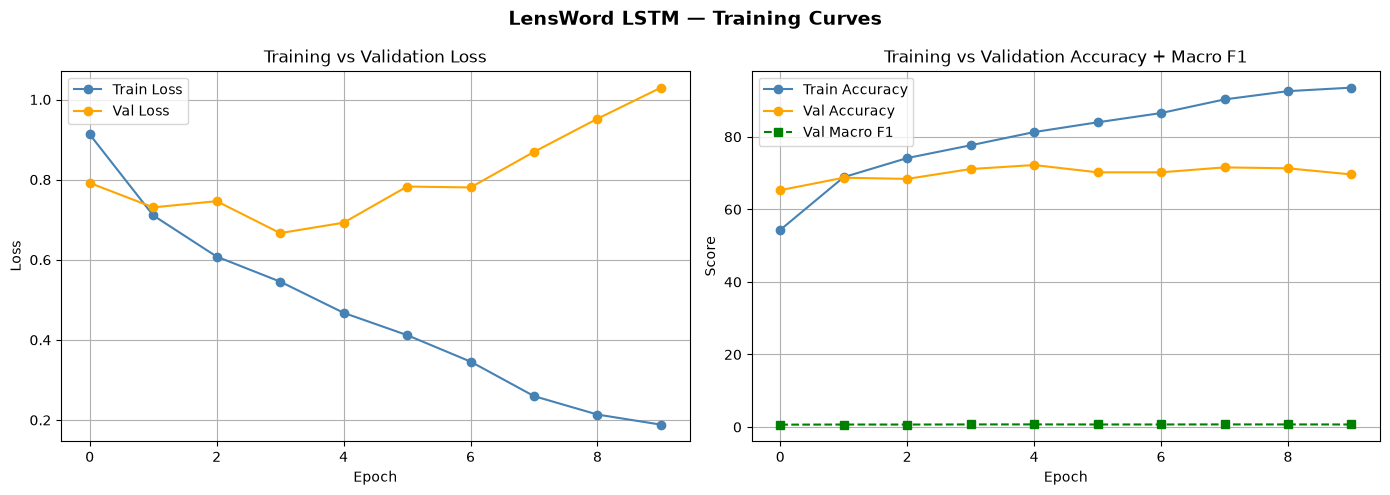

Training curves saved to models/training_curves.png


In [9]:
# ── CELL 9: Training curves ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses,    label='Train Loss',     color='steelblue', marker='o')
ax1.plot(val_losses,      label='Val Loss',       color='orange',    marker='o')
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accuracies, label='Train Accuracy', color='steelblue', marker='o')
ax2.plot(val_accuracies,   label='Val Accuracy',   color='orange',    marker='o')
ax2.plot(val_macro_f1s,    label='Val Macro F1',   color='green',     marker='s', linestyle='--')
ax2.set_title('Training vs Validation Accuracy + Macro F1')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(True)

plt.suptitle('LensWord LSTM — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved to models/training_curves.png")

In [10]:
# ── CELL 10: Evaluate best model on test set ──
# Load the best checkpoint and evaluate on held-out test set
model.load_state_dict(torch.load(MODEL_SAVE_PATH, weights_only=True))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        predictions = model(batch_X)
        predicted_labels = predictions.argmax(dim=1)
        all_preds.extend(predicted_labels.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

label_names = ['Negative', 'Neutral', 'Positive']
test_accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels) * 100
test_macro_f1 = f1_score(all_labels, all_preds, average='macro')

print("=" * 55)
print("TEST SET RESULTS (best checkpoint by Val Macro F1)")
print("=" * 55)
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Test Macro F1: {test_macro_f1:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=label_names))

TEST SET RESULTS (best checkpoint by Val Macro F1)
Test Accuracy: 72.62%
Test Macro F1: 0.7263

              precision    recall  f1-score   support

    Negative       0.73      0.76      0.75       371
     Neutral       0.70      0.59      0.64       361
    Positive       0.75      0.85      0.79       298

    accuracy                           0.73      1030
   macro avg       0.73      0.73      0.73      1030
weighted avg       0.72      0.73      0.72      1030



In [11]:
# ── CELL 11: Save metrics.json for provenance ──
# Error 10 fix: all reported figures saved to a single committed file
# README and report must quote only from this file

metrics = {
    "dataset": "amazon_yelp_combined.csv",
    "seed": SEED,
    "n_train": int(X_train.shape[0]),
    "n_val":   int(X_val.shape[0]),
    "n_test":  int(X_test.shape[0]),
    "epochs_run": len(train_losses),
    "best_val_macro_f1": round(best_val_macro_f1, 4),
    "test_accuracy":     round(test_accuracy, 2),
    "test_macro_f1":     round(test_macro_f1, 4),
    "per_class_f1": {
        label_names[i]: round(f1_score(all_labels, all_preds, average=None)[i], 4)
        for i in range(3)
    },
    "checkpoint_metric": "validation_macro_f1",
    "optimizer": "AdamW",
    "weight_decay": 1e-4,
    "class_weights": class_weights.numpy().tolist(),
    "smote_applied": False,
    "vocab_fitted_on": "training_partition_only"
}

with open('../models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("metrics.json saved to models/metrics.json")
print(json.dumps(metrics, indent=2))

metrics.json saved to models/metrics.json
{
  "dataset": "amazon_yelp_combined.csv",
  "seed": 42,
  "n_train": 7720,
  "n_val": 1544,
  "n_test": 1030,
  "epochs_run": 10,
  "best_val_macro_f1": 0.7239,
  "test_accuracy": 72.62,
  "test_macro_f1": 0.7263,
  "per_class_f1": {
    "Negative": 0.7467,
    "Neutral": 0.6396,
    "Positive": 0.7925
  },
  "checkpoint_metric": "validation_macro_f1",
  "optimizer": "AdamW",
  "weight_decay": 0.0001,
  "class_weights": [
    0.9263259172439575,
    0.9520286321640015,
    1.1493226289749146
  ],
  "smote_applied": false,
  "vocab_fitted_on": "training_partition_only"
}


In [12]:
# ── CELL 12: Training summary ──
print("=" * 50)
print("TRAINING SUMMARY — LensWord (Fixed)")
print("=" * 50)
print(f"Seed:                {SEED}")
print(f"Dataset:             amazon_yelp_combined.csv")
print(f"Training samples:    {X_train.shape[0]}")
print(f"Validation samples:  {X_val.shape[0]}")
print(f"Test samples:        {X_test.shape[0]}")
print(f"Epochs run:          {len(train_losses)}")
print(f"Best Val Macro F1:   {best_val_macro_f1:.4f}")
print(f"Test Accuracy:       {test_accuracy:.2f}%")
print(f"Test Macro F1:       {test_macro_f1:.4f}")
print(f"Checkpoint metric:   Validation Macro F1")
print(f"Optimizer:           AdamW (weight_decay=1e-4)")
print(f"SMOTE applied:       No")
print(f"Metrics saved:       models/metrics.json")
print(f"Model saved:         models/lensword_model.pt")
print("=" * 50)

TRAINING SUMMARY — LensWord (Fixed)
Seed:                42
Dataset:             amazon_yelp_combined.csv
Training samples:    7720
Validation samples:  1544
Test samples:        1030
Epochs run:          10
Best Val Macro F1:   0.7239
Test Accuracy:       72.62%
Test Macro F1:       0.7263
Checkpoint metric:   Validation Macro F1
Optimizer:           AdamW (weight_decay=1e-4)
SMOTE applied:       No
Metrics saved:       models/metrics.json
Model saved:         models/lensword_model.pt


In [13]:
# ── 3-SEED REPRODUCIBILITY RUN ──
# Advisor requirement: report mean ± std over at least 3 seeds
import json
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

seeds = [42, 7, 123]
results = []

print("Running 3-seed experiment...")
print("=" * 65)

for seed in seeds:
    # Set seed
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # Fresh model
    model_seed = LensWordLSTM(
        vocab_size=MAX_VOCAB_SIZE,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT
    )

    # Fresh optimizer
    optimizer_seed = optim.AdamW(model_seed.parameters(),
                                  lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler_seed = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_seed, mode='min', factor=0.5, patience=2)

    best_f1  = 0
    no_improve = 0
    best_state = None

    for epoch in range(NUM_EPOCHS):
        train_epoch(model_seed, train_loader, optimizer_seed, criterion)
        val_loss, val_acc, val_f1 = evaluate(model_seed, val_loader, criterion)
        scheduler_seed.step(val_loss)

        if val_f1 > best_f1:
            best_f1 = val_f1
            no_improve = 0
            best_state = {k: v.clone() for k, v in model_seed.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= 5:
                break

    # Evaluate best checkpoint on test set
    model_seed.load_state_dict(best_state)
    model_seed.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            preds = model_seed(batch_X).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    test_acc = accuracy_score(all_labels, all_preds) * 100
    test_f1  = f1_score(all_labels, all_preds, average='macro')

    results.append({'seed': seed, 'test_accuracy': test_acc, 'test_macro_f1': test_f1})
    print(f"Seed {seed:3d} | Test Accuracy: {test_acc:.2f}% | Test Macro F1: {test_f1:.4f}")

print("=" * 65)

# Calculate mean and std
accs = [r['test_accuracy'] for r in results]
f1s  = [r['test_macro_f1'] for r in results]

print(f"Test Accuracy: {np.mean(accs):.2f}% ± {np.std(accs):.2f}%")
print(f"Test Macro F1: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")

# Save to metrics.json
with open('../models/metrics.json', 'r') as f:
    metrics = json.load(f)

metrics['multi_seed'] = {
    'seeds': seeds,
    'per_seed': results,
    'mean_accuracy': round(np.mean(accs), 2),
    'std_accuracy':  round(np.std(accs), 2),
    'mean_macro_f1': round(np.mean(f1s), 4),
    'std_macro_f1':  round(np.std(f1s), 4)
}

with open('../models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("\nMulti-seed results saved to models/metrics.json")

Running 3-seed experiment...
Seed  42 | Test Accuracy: 72.62% | Test Macro F1: 0.7263
Seed   7 | Test Accuracy: 71.84% | Test Macro F1: 0.7205
Seed 123 | Test Accuracy: 71.17% | Test Macro F1: 0.7136
Test Accuracy: 71.88% ± 0.59%
Test Macro F1: 0.7201 ± 0.0052

Multi-seed results saved to models/metrics.json
